# 데이터 탐색 — Breast Cancer Wisconsin

모델을 만들기 전에 **데이터를 먼저 이해**해야 합니다.  
이 노트북은 `logistic_regression.ipynb`에서 사용하는 데이터셋을 탐색합니다.

**데이터셋**: Breast Cancer Wisconsin (Diagnostic)  
**목표**: 종양이 **악성(malignant)** 인지 **양성(benign)** 인지 분류  
**출처**: `sklearn.datasets.load_breast_cancer()` — 별도 다운로드 불필요

### 이 노트북에서 배울 것
- 각 피처(feature)가 실제로 무엇을 의미하는지
- 클래스가 균형 잡혀 있는지
- 어떤 피처가 분류에 가장 유용한지
- 왜 학습 전에 정규화(standardization)가 필요한지

In [19]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

from tool import (
    plot_class_distribution,
    plot_mean_feature_histograms,
    plot_feature_separability,
    plot_correlation_heatmap,
    plot_standardization_boxplots,
)

## 1. 데이터 불러오기

In [20]:
raw = load_breast_cancer()

df = pd.DataFrame(raw.data, columns=raw.feature_names)
df["label"] = raw.target  # 0 = 악성, 1 = 양성

print("Shape  :", df.shape)
print("Classes:", raw.target_names)
df.head()

Shape  : (569, 31)
Classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. 피처(Feature)란 무엇인가?

각 샘플은 **유방 종양을 촬영한 디지털 이미지**입니다.  
이미지에서 10가지 속성을 측정하고, 각 속성에 대해 3가지 통계값을 계산합니다.

| 통계값 | 의미 |
|--------|------|
| `mean` | 이미지 내 세포들의 평균값 |
| `error` | 표준 오차 (값이 얼마나 퍼져 있는지) |
| `worst` | 가장 큰 3개 값의 평균 |

10가지 기본 속성:

| 속성 | 의미 |
|------|------|
| radius | 중심에서 외곽까지의 평균 거리 |
| texture | 픽셀 회색조 값의 변화량 |
| perimeter | 세포핵의 둘레 |
| area | 세포핵의 넓이 |
| smoothness | 반지름 길이의 국소 변화량 |
| compactness | 둘레² / 넓이 − 1 |
| concavity | 외곽선의 오목한 부분의 심각도 |
| concave points | 외곽선에서 오목한 지점의 수 |
| symmetry | 세포핵의 대칭성 |
| fractal dimension | 외곽선 복잡도 |

→ 10가지 속성 × 3가지 통계값 = **총 30개 피처**

In [21]:
print("Feature names:")
for i, name in enumerate(raw.feature_names):
    print(i + 1, name)

Feature names:
1 mean radius
2 mean texture
3 mean perimeter
4 mean area
5 mean smoothness
6 mean compactness
7 mean concavity
8 mean concave points
9 mean symmetry
10 mean fractal dimension
11 radius error
12 texture error
13 perimeter error
14 area error
15 smoothness error
16 compactness error
17 concavity error
18 concave points error
19 symmetry error
20 fractal dimension error
21 worst radius
22 worst texture
23 worst perimeter
24 worst area
25 worst smoothness
26 worst compactness
27 worst concavity
28 worst concave points
29 worst symmetry
30 worst fractal dimension


## 3. 클래스 분포

데이터가 균형 잡혀 있나요? 클래스 불균형이 심하면 정확도(accuracy) 지표가 의미를 잃을 수 있습니다.

malignant: 212
benign   : 357


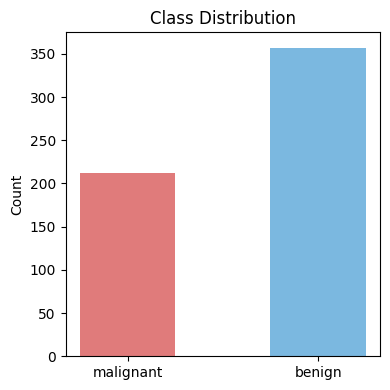

In [22]:
n_malignant = sum(df["label"] == 0)
n_benign    = sum(df["label"] == 1)

print("malignant:", n_malignant)
print("benign   :", n_benign)

plot_class_distribution(n_malignant, n_benign)

## 4. 기초 통계량

피처별 값의 범위를 확인합니다.  
스케일이 피처마다 매우 다릅니다 — 이것이 정규화가 필요한 이유입니다.

In [23]:
# label 열을 제외하고 기초 통계량 확인
feature_cols = [c for c in df.columns if c != "label"]
stats = df[feature_cols].describe()
stats.T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## 5. 클래스별 피처 분포

악성과 양성 종양은 피처 분포가 다를까요?  
가장 직관적인 `mean` 피처 10개를 시각화합니다.

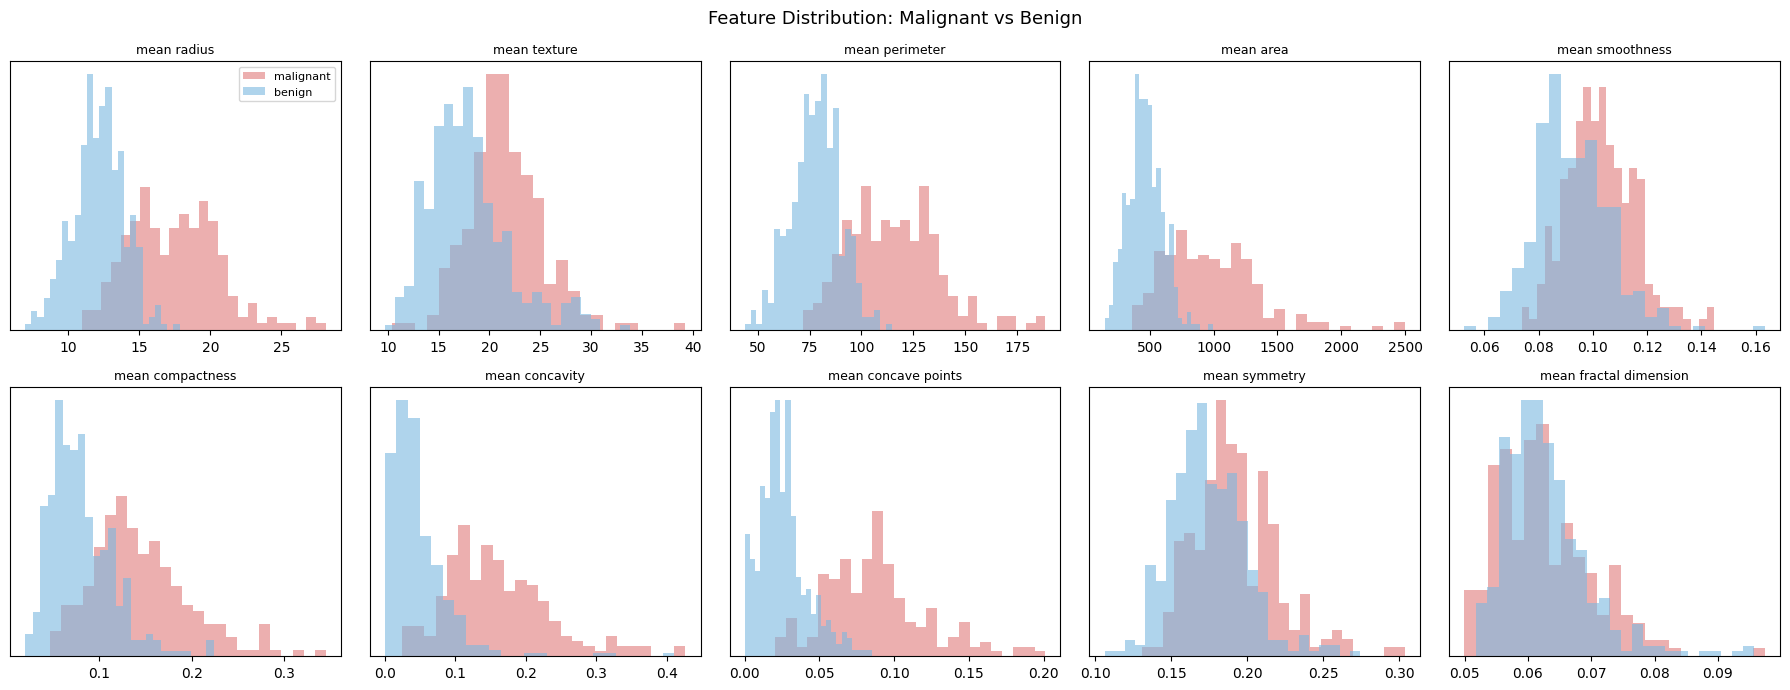

In [24]:
mean_features = [col for col in feature_cols if col.startswith("mean ")]

# 악성 / 양성 데이터 분리
df_malignant = df[df["label"] == 0]
df_benign    = df[df["label"] == 1]

plot_mean_feature_histograms(df_malignant, df_benign, mean_features)

## 6. 어떤 피처가 분류에 가장 유용한가?

클래스 간 평균 차이를 표준편차로 나눈 값 — 클수록 두 클래스를 잘 구분하는 피처입니다.

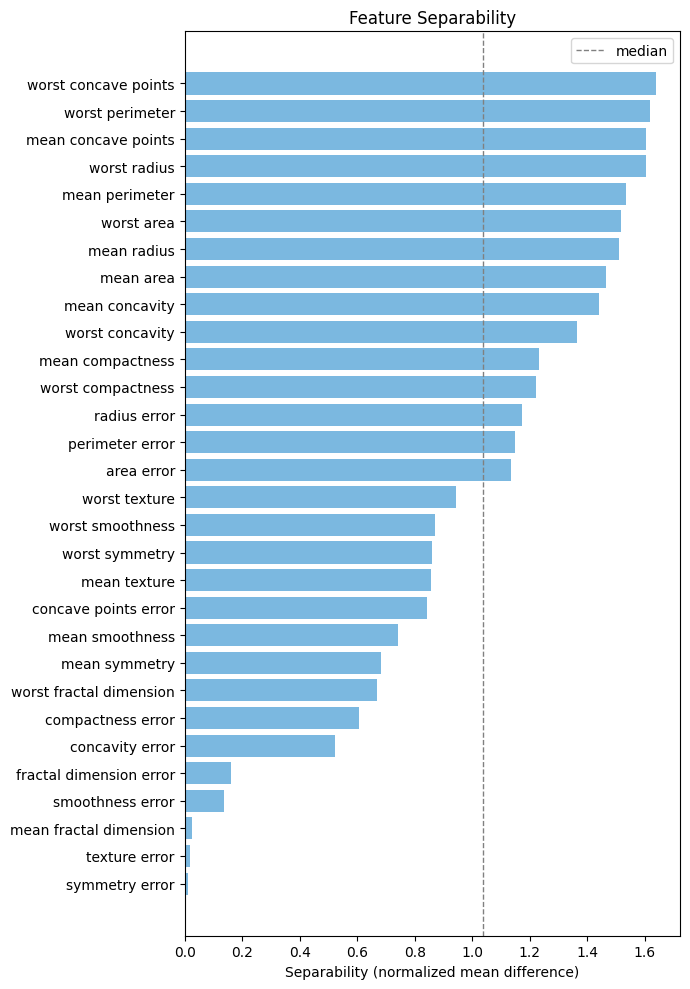

In [25]:
mean_diff    = abs(df_malignant[feature_cols].mean() - df_benign[feature_cols].mean())
std_all      = df[feature_cols].std()
separability = mean_diff / std_all
separability = separability.sort_values(ascending=True)

plot_feature_separability(separability)

## 7. 피처 간 상관관계

많은 피처들이 서로 높은 상관관계를 가집니다 (예: `radius mean`과 `area mean`).  
로지스틱 회귀 학습 자체에는 문제가 없지만, 모델 해석 시 주의해야 합니다.

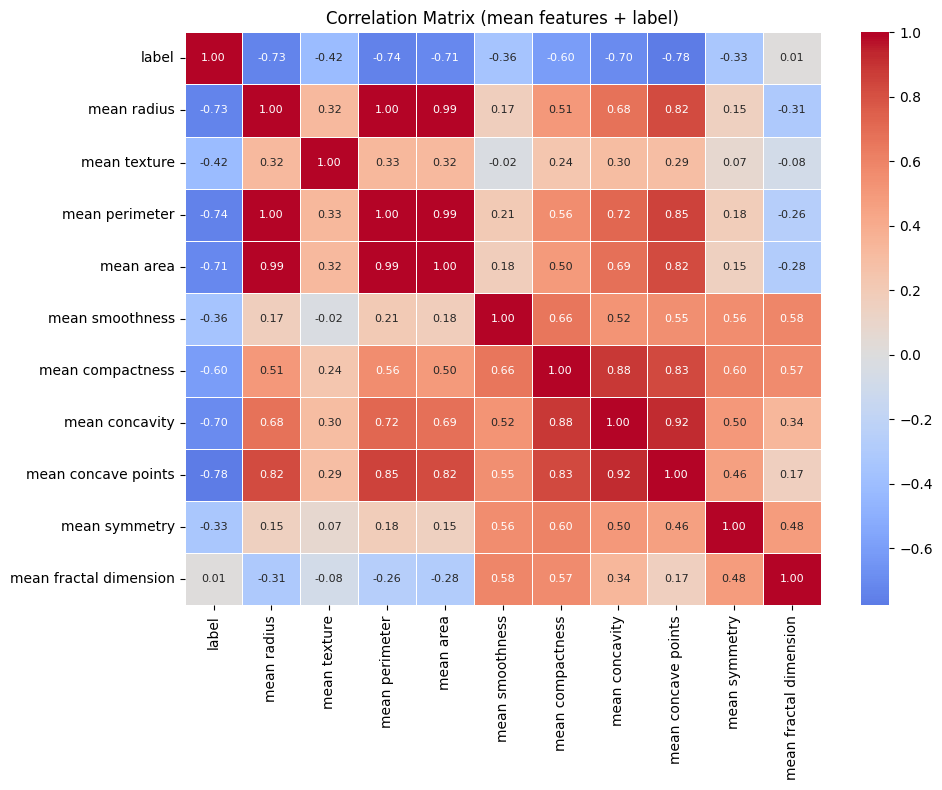

In [28]:
# label 열을 포함해서 상관관계 계산 — 각 피처가 악성/양성과 얼마나 연관되는지 확인
corr = df[["label"] + mean_features].corr()

plot_correlation_heatmap(corr)

## 8. 정규화가 왜 필요한가?

피처 간 스케일 차이가 매우 큽니다.  
정규화 없이 학습하면 스케일이 큰 피처가 경사하강법을 지배하게 됩니다.

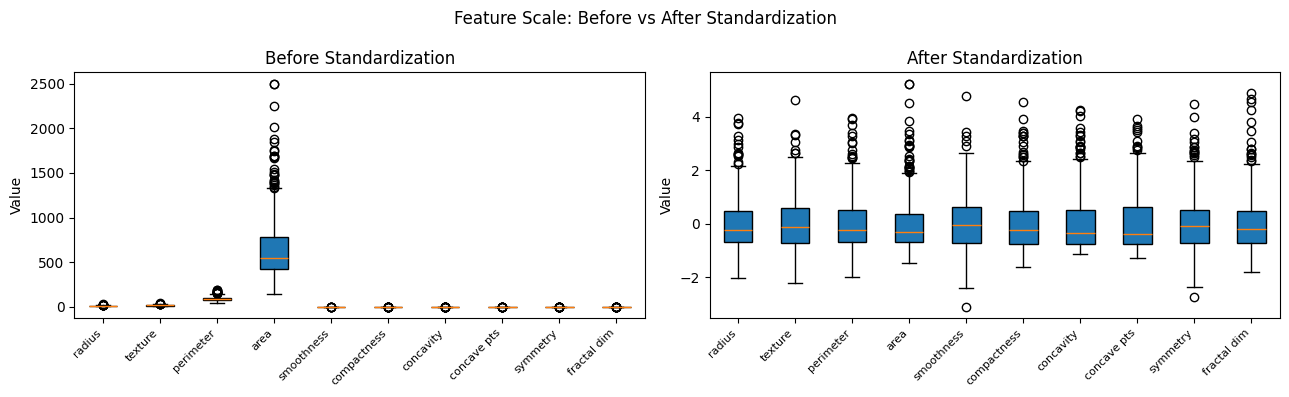

In [27]:
X_raw = df[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

plot_standardization_boxplots(X_raw, X_scaled)

## 정리

| 발견 | 모델에 주는 시사점 |
|------|------------------|
| 569개 샘플, 30개 피처 | 작은 데이터셋 — 복잡한 모델 불필요 |
| 양성 63% / 악성 37% | 약한 불균형 — 정확도 지표 사용 가능 |
| `worst` 피처의 판별력이 높음 | 모델이 이 피처들에 크게 의존할 것 |
| 크기 관련 피처들 간 높은 상관관계 | radius, perimeter, area 모두 크기를 측정하므로 당연한 결과 |
| 피처 스케일 차이가 매우 큼 (0.001 ~ 2500) | **학습 전 반드시 정규화 필요** |

이제 `logistic_regression.ipynb`를 열어보세요 — 모든 전처리 단계가 이해될 것입니다.